## Using Linear Regression to Understand Causality.
05 — The Unreasonable Effectiveness of Linear Regression <br>
06 — Grouped and Dummy Regression <br>
07 — Beyond Confounders

In [9]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
import statsmodels.formula.api as smf
style.use("fivethirtyeight")
import os
os.getcwd()
os.chdir("/Users/hiro/Documents/github/Causal_Inference/")

## Lecture 5: Regression

Observed outcome is: 
$Y_i = Y_{0i} + T_i(Y_{1i}-Y_{0i})$ <br>

Average Treatment Effect is:
$ATE = E[Y_{1}-Y_{0}]$ <br>

If treatment binary and randomized, then kappa is just the difference in means, ATE

$$Y_i = \beta_0 + \kappa T_i + u_i,$$

**Heuristic:** with only a treatment dummy, regression is just a fancy way of comparing treated and control averages.

Example:
$exam_i = \beta_0 + \kappa Online_i + u_i$ <br>


Now for multivariate:

In a multivariate regression
$$
Y_i = \beta_0 + \kappa T_i + \beta'X_i + u_i,$$
the treatment coefficient can be written as

$$\kappa = \frac{\operatorname{Cov}(Y_i,\tilde T_i)}{\operatorname{Var}(\tilde T_i)},$$

where $\tilde T_i$ is the residual from regressing $T_i$ on $X_i$.

**Heuristic:** first remove from treatment everything explained by the controls; then see how the remaining variation in treatment is associated with the outcome.

So regression tries to make treatment **as good as random conditional on \(X\)**.

$y_i = \beta_0 + \kappa T_i + \beta_1 X_{1i} + \dots + \beta_{k}X_{ki} + u_i$ <br>

Now, for non-random data:  regression helps because it compares units with the same observed controls $X$. For example, if we control for IQ, experience, family background, etc., the coefficient on education is the effect of education **holding those factors fixed**.

But this is causal only if the relevant confounders are in \(X\).

---

## Omitted variable bias

If the true model is

$Y_i = \alpha + \kappa T_i + \beta' A_i + u_i$

but we omit $A_i$, then the short regression coefficient is

$$\frac{\operatorname{Cov}(Y_i,T_i)}{\operatorname{Var}(T_i)} =\kappa + \beta'\delta_A,$$

where $\delta_A$ is the effect of the omitted variable on treatment.

**Heuristic:** omitted variable bias appears when the omitted variable affects both:
1. the outcome, and
2. the treatment.

So there is no OVB if the omitted variable affects only one side, or neither.

---

## Core takeaway

Regression is powerful because:

1. in randomized settings, it recovers the treatment effect directly;
2. with controls, it residualizes treatment and compares outcome variation to the part of treatment not explained by \(X\);
3. in observational data, it is causal only under a **no omitted confounders** type assumption.

In short:

> Regression does not magically create causality.  
> It isolates variation in treatment.  
> That variation is causal only if the remaining variation is not confounded.

**How to know if all confounders included?** I’m sorry to bring it to you, but that will depend on our ability to argue in favor or against that fact that all confounders have been included in the model. Personally, I think they haven’t. 

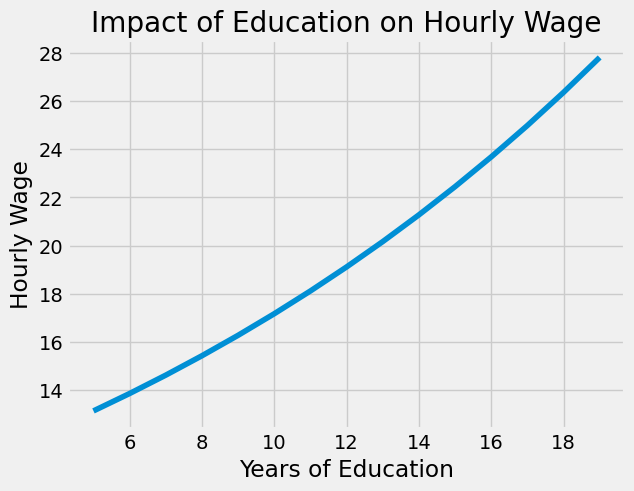

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,1.1156,0.232,4.802,0.000,0.659,1.572
educ,0.0411,0.010,4.075,0.000,0.021,0.061
IQ,0.0038,0.001,2.794,0.005,0.001,0.006
exper,0.0153,0.005,3.032,0.003,0.005,0.025
tenure,0.0094,0.003,2.836,0.005,0.003,0.016
age,0.0086,0.006,1.364,0.173,-0.004,0.021
married,0.1795,0.053,3.415,0.001,0.076,0.283
black,-0.0801,0.063,-1.263,0.207,-0.205,0.044
south,-0.0397,0.035,-1.129,0.259,-0.109,0.029
urban,0.1926,0.036,5.418,0.000,0.123,0.262


In [12]:
wage = pd.read_csv("./data/wage.csv").dropna()
wage = wage.assign(hwage=wage["wage"]/wage["hours"],
                   lhwage=np.log(wage["wage"]/wage["hours"]))

model_1 = smf.ols('np.log(hwage) ~ educ', data=wage).fit()
model_1.summary().tables[1]

from matplotlib import pyplot as plt
from matplotlib import style
style.use("fivethirtyeight")

x = np.array(range(5, 20))
plt.plot(x, np.exp(model_1.params["Intercept"] + model_1.params["educ"] * x))
plt.xlabel("Years of Education")
plt.ylabel("Hourly Wage")
plt.title("Impact of Education on Hourly Wage")
plt.show()

controls = ['IQ', 'exper', 'tenure', 'age', 'married', 'black',
            'south', 'urban', 'sibs', 'brthord', 'meduc', 'feduc']

X = wage[controls].assign(intercep=1)
t = wage["educ"]
y = wage["lhwage"]

beta_aux = np.linalg.lstsq(X, t, rcond=None)[0]
t_tilde = t - X.dot(beta_aux)

kappa = t_tilde.cov(y) / t_tilde.var()
kappa

model_2 = smf.ols('lhwage ~ educ +' + '+'.join(controls), data=wage).fit()
model_2.summary().tables[1]

## Chapter 6: Grouped and Dummy Regression

This phenomenon of having a region of low variance and another of high variance is called heteroskedasticity. Grouped data are common. Because of confidentiality. Governments and firms can’t give away personal data because of privacy. If export data, do by means grouping data. Individuals then are no longer uniquely identifiable.

# Lecture 6: Grouped and Dummy Regression

### Grouped regression

When data are aggregated into groups, each row may represent many original observations. Bigger groups contain more information and usually have lower variance, so they should matter more in estimation. This is why grouped regression should use **weights equal to group size**. Unweighted OLS gives each group the same importance and can distort the slope. 

**Heuristic:** grouped data are fine, but large groups should count more than small groups.

### Dummy regression

A categorical variable is included in regression by turning it into **dummy variables**: \(0/1\) indicators for categories, leaving one category out as the **baseline**. The omitted category is the reference group. 

If treatment is binary,

$Y_i = \beta_0 + \beta_1 T_i + e_i,$

then:
- $\beta_0 = E[Y \mid T=0]\$. <br>
  
- $\beta_1 = E[Y \mid T=1] - E[Y \mid T=0]$. The dummy coefficient is just the **difference in means**. If randomized, ATE.



If we add controls,

$Y_i = \beta_0 + \beta_1 T_i + \beta_2 X_i + e_i,$

then $\beta_1\$ becomes the **conditional difference in means**, holding \(X\) fixed. This implies a constant treatment effect across values of \(X\) unless we add interactions. 

With an interaction,

$Y_i = \beta_0 + \beta_1 T_i + \beta_2 X_i + \beta_3 (T_iX_i) + e_i,$$

the treatment effect becomes

$\beta_1 + \beta_3 X_i.$

So the effect of treatment can vary with $X$. This is effect heterogeneity / effect modification. :contentReference[oaicite:5]{index=5}

If a regressor is treated entirely as categorical, like $C(\text{educ})$, each category gets its own coefficient relative to the baseline. This is a flexible, nonparametric way to allow different mean outcomes by category. 

### Core takeaway

- Grouped data: use **means + counts + WLS**
- Binary dummy: coefficient = **difference in means**
- Dummy + controls: coefficient = **conditional difference in means**
- Dummy + interaction: treatment effect can **vary with \(X\)** 

---

## Implementation

### Grouped data
1. Group the data
2. Compute:
   - mean of \(Y\)
   - mean of regressors
   - count per group
3. Run weighted least squares with weights = group counts :contentReference[oaicite:8]{index=8}

Example:
```python
group_df = (df
    .assign(count=1)
    .groupby("educ")
    .agg({"lhwage": "mean", "IQ": "mean", "count": "count"})
    .reset_index())

smf.wls("lhwage ~ educ + IQ", data=group_df, weights=group_df["count"]).fit()

Fear not! Regression doesn’t need big data to work! What we can do is provide weights to our linear regression model. This way, it will consider groups with higher sample size more than the small groups. Notice how I’ve replaced the smf.ols with smf.wls, for weighted least squares. It’s hard to notice, but it will make all the difference.

Notice how the parameter estimate of educ in the grouped model is very close to the one in the ungrouped data (actually, they are the same in this case). Also, even with only 10 data points, we’ve managed to get a statistically significant coefficient. That’s because, although we have fewer points, grouping also lowers the variance by a lot. Also notice how the standard error is a bit smaller and the t statistics is a bit larger. That’s because some information about the variance is lost, so we have to be more conservative. Once we group the data, we don’t know how large the variance is within each group. Compare the results above with what we would have with the non weighted model below.

The parameter estimate is smaller. What is happening here is that the regression is placing equal weight for all points. If we plot the model along the grouped points, we see that the non weighted model is giving more importance to small points in the lower left than it should. As a consequence, the line has a lower slope.

   educ    lhwage  count
0     9  2.856475     10
1    10  2.786911     35
2    11  2.855997     43
3    12  2.922168    393
4    13  3.021182     85
5    14  3.042352     77
6    15  3.090766     45
7    16  3.176184    150
8    17  3.246566     40
9    18  3.144257     57


/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)
/opt/anaconda3/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


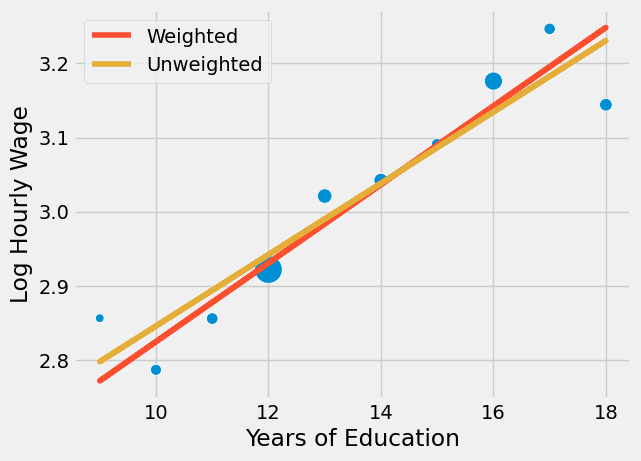

In [13]:
# Load only the columns we need
wage = pd.read_csv("./data/wage.csv")[["wage", "lhwage", "educ", "IQ"]]

# Peek at the data
wage.head()

# Regression using individual-level data
model_1 = smf.ols('lhwage ~ educ', data=wage).fit()
model_1.summary().tables[1]

# Collapse the data by education level:
# for each value of educ, compute mean log wage and group size
group_wage = (
    wage
    .assign(count=1)
    .groupby("educ")
    .agg({"lhwage": "mean", "count": "count"})
    .reset_index()
)

print(group_wage)

# Weighted regression on grouped data:
# bigger groups get more weight
model_2 = smf.wls('lhwage ~ educ', data=group_wage, weights=group_wage["count"]).fit()
model_2.summary().tables[1]

# Unweighted regression on grouped data:
# each education group counts the same
model_3 = smf.ols('lhwage ~ educ', data=group_wage).fit()
model_3.summary().tables[1]

# Plot group means; point size shows how many observations are in each group
sns.scatterplot(x="educ", y="lhwage", size="count", legend=False, data=group_wage, sizes=(40, 400))

# Add fitted lines
plt.plot(wage["educ"], model_2.predict(wage["educ"]), c="C1", label="Weighted")
plt.plot(wage["educ"], model_3.predict(wage["educ"]), c="C2", label="Unweighted")

plt.xlabel("Years of Education")
plt.ylabel("Log Hourly Wage")
plt.legend();

In [ ]:
sns.scatterplot(x="educ", y = "lhwage", size="count", legend=False, data=group_wage, sizes=(40, 400))
plt.plot(wage["educ"], model_2.predict(wage["educ"]), c="C1", label = "Weighted")
plt.plot(wage["educ"], model_3.predict(wage["educ"]), c="C2", label = "Non Weighted")
plt.xlabel("Years of Education")
plt.ylabel("Log Hourly Wage")
plt.legend();

group_wage = (wage
              .assign(count=1)
              .groupby("educ")
              .agg({"lhwage":"mean", "IQ":"mean", "count":"count"})
              .reset_index())

model_4 = smf.wls('lhwage ~ educ + IQ', data=group_wage, weights=group_wage["count"]).fit()
print("Number of observations:", model_4.nobs)
model_4.summary().tables[1]

In [ ]:
wage = (pd.read_csv("./data/wage.csv")
        .assign(hwage=lambda d: d["wage"] / d["hours"])
        .assign(T=lambda d: (d["educ"] > 12).astype(int)))

wage[["hwage", "IQ", "T"]].head()

smf.ols('hwage ~ T', data=wage).fit().summary().tables[1]

m = smf.ols('hwage ~ T+IQ', data=wage).fit()
plt_df = wage.assign(y_hat = m.fittedvalues)

plt.plot(plt_df.query("T==1")["IQ"], plt_df.query("T==1")["y_hat"], c="C1", label="T=1")
plt.plot(plt_df.query("T==0")["IQ"], plt_df.query("T==0")["y_hat"], c="C2", label="T=0")
plt.title(f"E[T=1|IQ] - E[T=0|IQ] = {round(m.params['T'], 2)}")
plt.ylabel("Wage")
plt.xlabel("IQ")
plt.legend();

m = smf.ols('hwage ~ T*IQ', data=wage).fit()
plt_df = wage.assign(y_hat = m.fittedvalues)

plt.plot(plt_df.query("T==1")["IQ"], plt_df.query("T==1")["y_hat"], c="C1", label="T=1")
plt.plot(plt_df.query("T==0")["IQ"], plt_df.query("T==0")["y_hat"], c="C2", label="T=0")
plt.title(f"E[T=1|IQ] - E[T=0|IQ] = {round(m.params['T'], 2)}")
plt.ylabel("Wage")
plt.xlabel("IQ")
plt.legend();

wage_ed_bins = (wage
                .assign(IQ_bins = lambda d: pd.qcut(d["IQ"], q=4, labels=range(4)))
                [["hwage", "educ", "IQ_bins"]])

wage_ed_bins.head()

model_dummy = smf.ols('hwage ~ C(educ)', data=wage).fit()
model_dummy.summary().tables[1]

plt.scatter(wage["educ"], wage["hwage"])
plt.plot(wage["educ"].sort_values(), model_dummy.predict(wage["educ"].sort_values()), c="C1")
plt.xlabel("Years of Education")
plt.ylabel("Hourly Wage");

t1 = wage.query("educ==17")["hwage"]
t0 = wage.query("educ==9")["hwage"]
print("E[Y|T=9]:", t0.mean())
print("E[Y|T=17]-E[Y|T=9]:", t1.mean() - t0.mean())

model_dummy_2 = smf.ols('hwage ~ C(educ) + C(IQ_bins)', data=wage_ed_bins).fit()
model_dummy_2.summary().tables[1]

## Chapter 7: Beyond Confounders

Not every useful control is a confounder.  
Some controls help **precision**, some hurt **precision**, and some create **bias**. Adding correlation variables are good (even if not causation), but adding predictors of treatment $T$ is not good. Reduces variation in treatment.

## Good controls

If $X$ predicts the outcome $Y$, adding it can reduce residual variance and make the treatment effect easier to detect, even if $X$ does **not** cause treatment. 


$$Y = \alpha + \tau T + \beta X + u$$


**Heuristic:** good predictors of \(Y\) make the regression less noisy.  
They help with **precision**, not identification. 

## Mostly harmful controls

If a variable predicts $T$ but not $Y$, controlling for it is a bad idea. It removes variation in treatment without helping explain the outcome. This increases standard errors and makes the treatment effect harder to estimate. 

**Heuristic:** controls should explain $Y$, not just $T$. 

So:

- predictor of $Y$ only: often good
- predictor of $T$ only: mostly harmful 

## Selection bias

The truly bad controls are variables that are:

$T \to X \to Y
\qquad\text{or}\qquad
T \to X \leftarrow Y
$

That is, either:

- a **mediator** on the causal path, or
- a **collider** / common effect of treatment and outcome. :contentReference[oaicite:6]{index=6}

Controlling for them changes the estimand or creates spurious association.

**Heuristic:** never control for something caused by treatment if your goal is the total effect. :contentReference[oaicite:7]{index=7}

## One-line takeaway

> Good controls reduce noise.  
> Bad controls reduce treatment variation or create selection bias.

Simple regression
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    669.9764      2.061    325.116      0.000     665.937     674.016
email         -0.6203      2.941     -0.211      0.833      -6.387       5.146

Regression with good controls
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      490.8653      9.715     50.527      0.000     471.820     509.911
email            4.4304      2.130      2.080      0.038       0.255       8.606
credit_limit     0.1511      0.008     18.833      0.000       0.135       0.167
risk_score      -8.0516     38.424     -0.210      0.834     -83.379      67.276

Residual-on-residual regression
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------

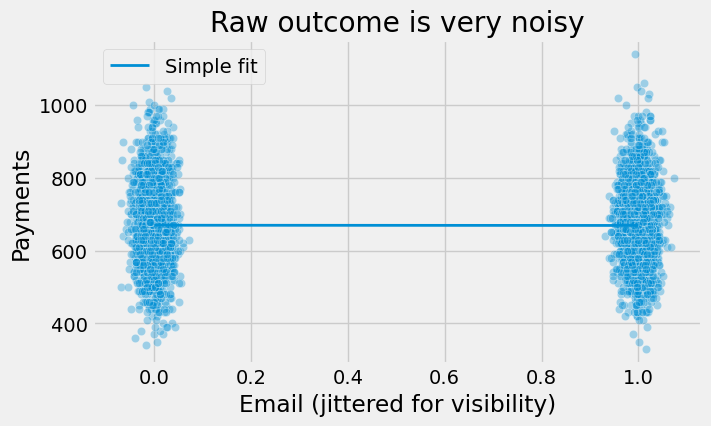

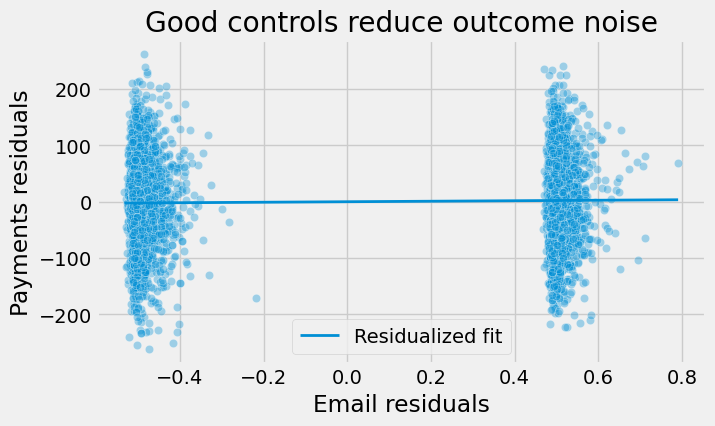


Takeaway:
- `email` is causal because treatment was randomized.
- Adding `credit_limit` and `risk_score` is useful because they help explain `payments`.
- Good controls improve precision by reducing residual variance.
- The treatment coefficient from the full regression matches the residual-on-residual regression.


In [16]:
# ------------------------------------------------------------
# Beyond Confounders: one complete example
# ------------------------------------------------------------
# Main idea:
# In a randomized experiment, `email` is already causal, so
#   payments ~ email
# identifies the ATE.
#
# Adding pre-treatment variables like `credit_limit` and `risk_score`
# does NOT fix confounding here (randomization already did that).
# Instead, they help reduce noise in `payments`, which can make the
# treatment effect easier to detect.
#
# So:
# - controls that predict Y can improve precision
# - controls that do not help predict Y are often not useful
# - post-treatment variables should not be controlled for
# ------------------------------------------------------------

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Load the randomized experiment data
data = pd.read_csv("./data/collections_email.csv")

# Quick look
data.head()


# ------------------------------------------------------------
# 1) Baseline causal estimate: randomized treatment only
# ------------------------------------------------------------
# Since email was randomized, the coefficient on `email` is already causal.
model_simple = smf.ols("payments ~ email", data=data).fit()

print("Simple regression")
print(model_simple.summary().tables[1])


# ------------------------------------------------------------
# 2) Add good controls
# ------------------------------------------------------------
# `credit_limit` and `risk_score` are measured before treatment.
# They may explain part of the variation in payments.
# If they do, the treatment coefficient can become more precise.
model_controls = smf.ols(
    "payments ~ email + credit_limit + risk_score",
    data=data
).fit()

print("\nRegression with good controls")
print(model_controls.summary().tables[1])


# ------------------------------------------------------------
# 3) Partialling-out view (same treatment coefficient)
# ------------------------------------------------------------
# This is the regression intuition:
# First remove from payments the part explained by the controls.
# Also remove from email the part explained by the controls.
# Then regress residualized payments on residualized email.
#
# Because treatment is randomized, controls should explain almost none
# of email, but they can explain a lot of payments.
model_email = smf.ols("email ~ credit_limit + risk_score", data=data).fit()
model_payments = smf.ols("payments ~ credit_limit + risk_score", data=data).fit()

residuals = pd.DataFrame({
    "res_email": model_email.resid,
    "res_payments": model_payments.resid
})

model_resid = smf.ols("res_payments ~ res_email", data=residuals).fit()

print("\nResidual-on-residual regression")
print(model_resid.summary().tables[1])

print("\nTreatment coefficient with controls: ", round(model_controls.params["email"], 4))
print("Treatment coefficient via partialling-out:", round(model_resid.params["res_email"], 4))


# ------------------------------------------------------------
# 4) Variance comparison
# ------------------------------------------------------------
# This shows the whole point:
# controls reduce the variance of the outcome, not of the randomized treatment.
print("\nVariance comparison")
print("Payments variance:          ", round(np.var(data["payments"]), 2))
print("Payments residual variance: ", round(np.var(residuals["res_payments"]), 2))
print("Email variance:             ", round(np.var(data["email"]), 4))
print("Email residual variance:    ", round(np.var(residuals["res_email"]), 4))


# ------------------------------------------------------------
# 5) Visualization 1: raw payments vs treatment
# ------------------------------------------------------------
# The cloud is very noisy: payments vary a lot within each treatment group.
# So even a real treatment effect can be hard to see.
plot_data = data.assign(
    email_jitter=data["email"] + np.random.normal(0, 0.02, size=len(data))
)

plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=plot_data,
    x="email_jitter",
    y="payments",
    alpha=0.35
)

xline = np.array([0, 1])
yline = model_simple.params["Intercept"] + model_simple.params["email"] * xline
plt.plot(xline, yline, linewidth=2, label="Simple fit")

plt.xlabel("Email (jittered for visibility)")
plt.ylabel("Payments")
plt.title("Raw outcome is very noisy")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 6) Visualization 2: residualized payments vs residualized treatment
# ------------------------------------------------------------
# After removing the part of payments explained by good controls,
# the outcome is less noisy. This makes the treatment effect clearer.
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=residuals,
    x="res_email",
    y="res_payments",
    alpha=0.35
)

x = np.linspace(residuals["res_email"].min(), residuals["res_email"].max(), 100)
y = model_resid.params["Intercept"] + model_resid.params["res_email"] * x
plt.plot(x, y, linewidth=2, label="Residualized fit")

plt.xlabel("Email residuals")
plt.ylabel("Payments residuals")
plt.title("Good controls reduce outcome noise")
plt.legend()
plt.show()


# ------------------------------------------------------------
# 7) Compact conclusion
# ------------------------------------------------------------
print("\nTakeaway:")
print("- `email` is causal because treatment was randomized.")
print("- Adding `credit_limit` and `risk_score` is useful because they help explain `payments`.")
print("- Good controls improve precision by reducing residual variance.")
print("- The treatment coefficient from the full regression matches the residual-on-residual regression.")